In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('healthcare_raw.csv')
data

,patient_id,name,age,gender,diagnosis,department,ward,admission_score,discharge_score,los_days,readmitted,cost_usd,bmi,systolic_bp,diastolic_bp,heart_rate,hba1c
0,EXL0001,Patient AA,-5,Female,Cardiac Arrhythmia,Pulmonology,HDU,34.2,57.1,17.0,False,47715.72,20.8,119.0,115.0,111.0,5.4
1,EXL0002,Patient BA,32,Female,Cardiac Arrhythmia,Endocrinology,Ward-B,51.0,65.8,26.0,False,31863.82,200.0,172.0,62.0,53.0,NaN
2,EXL0003,patient bb,78,Female,COPD,General Medicine,Day-Care,97.1,56.1,44.0,False,66886.84,26.5,138.0,102.0,105.0,6.7
3,EXL0004,Patient DA,38,MALE,COPD,Psychiatry,Ward-A,39.9,87.3,7.0,True,21861.47,31.9,178.0,108.0,97.0,9.6
4,EXL0005,Patient EA,41,Non-Binary,Anaemia,Psychiatry,ICU,30.7,74.4,42.0,False,79836.62,40.4,105.0,114.0,62.0,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,EXL0496,Patient BT,36,Male,Anaemia,General Medicine,ICU,47.2,71.8,27.0,False,54023.29,25.4,108.0,82.0,131.0,12.1
496,EXL0497,Patient CT,56,Male,Anaemia,Endocrinology,ICU,99.1,79.1,26.0,False,NaN,38.2,106.0,71.0,97.0,8.8
497,EXL0498,Patient DT,84,Non-Binary,Chronic Kidney Disease,Cardiology,HDU,70.1,78.7,19.0,False,34121.21,NaN,122.0,93.0,59.0,7.7
498,EXL0499,Patient ET,62,Male,Depression,Orthopaedics,Emergency,62.5,73.7,28.0,False,68605.22,35.1,165.0,95.0,70.0,11.3


In [4]:
data.shape

(500, 17)

In [5]:
data.describe(include='all')

,patient_id,name,age,gender,diagnosis,department,ward,admission_score,discharge_score,los_days,readmitted,cost_usd,bmi,systolic_bp,diastolic_bp,heart_rate,hba1c
count,500,500,500.000000,500,500,500,500,500.000000,500.000000,479.000000,500,475.000000,455.000000,459.000000,450.000000,461.000000,463.000000
unique,500,500,NaN,4,10,8,6,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
top,EXL0001,Patient AA,NaN,Male,Asthma,Pulmonology,HDU,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,NaN,175,56,78,91,NaN,NaN,NaN,402,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,52.124000,NaN,NaN,NaN,NaN,59.341200,70.424400,21.876827,NaN,40947.250905,30.519780,138.623094,88.360000,91.757050,8.500864
std,NaN,NaN,20.682363,NaN,NaN,NaN,NaN,23.736988,17.320354,12.645449,NaN,24306.472807,11.571688,26.812131,17.225718,25.204589,2.402623
min,NaN,NaN,-5.000000,NaN,NaN,NaN,NaN,20.000000,40.100000,1.000000,NaN,613.760000,16.000000,90.000000,60.000000,45.000000,0.100000
25%,NaN,NaN,34.000000,NaN,NaN,NaN,NaN,38.000000,55.400000,10.500000,NaN,19859.850000,23.100000,115.500000,72.000000,71.000000,6.400000
50%,NaN,NaN,52.000000,NaN,NaN,NaN,NaN,59.350000,71.800000,22.000000,NaN,40073.900000,29.800000,140.000000,87.000000,93.000000,8.500000
75%,NaN,NaN,70.250000,NaN,NaN,NaN,NaN,80.150000,84.850000,32.500000,NaN,62057.955000,37.500000,162.500000,103.000000,113.000000,10.600000


In [6]:
data.isnull().sum()

patient_id          0
name                0
age                 0
gender              0
diagnosis           0
department          0
ward                0
admission_score     0
discharge_score     0
los_days           21
readmitted          0
cost_usd           25
bmi                45
systolic_bp        41
diastolic_bp       50
heart_rate         39
hba1c              37
dtype: int64

In [7]:
data.columns.tolist()

['patient_id',
 'name',
 'age',
 'gender',
 'diagnosis',
 'department',
 'ward',
 'admission_score',
 'discharge_score',
 'los_days',
 'readmitted',
 'cost_usd',
 'bmi',
 'systolic_bp',
 'diastolic_bp',
 'heart_rate',
 'hba1c']

In [8]:
data.drop_duplicates(inplace=True)

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
# list all numeric columns
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
print(numeric_cols)

['age', 'admission_score', 'discharge_score', 'los_days', 'cost_usd', 'bmi', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'hba1c']


In [11]:
stats_profile=data[numeric_cols].describe().T
stats_profile['median']=data[numeric_cols].median()
stats_profile

,count,mean,std,min,25%,50%,75%,max,median
age,500.0,52.124000,20.682363,-5.00,34.00,52.00,70.250,87.00,52.00
admission_score,500.0,59.341200,23.736988,20.00,38.00,59.35,80.150,99.80,59.35
discharge_score,500.0,70.424400,17.320354,40.10,55.40,71.80,84.850,100.00,71.80
los_days,479.0,21.876827,12.645449,1.00,10.50,22.00,32.500,44.00,22.00
cost_usd,475.0,40947.250905,24306.472807,613.76,19859.85,40073.90,62057.955,84799.13,40073.90
bmi,455.0,30.519780,11.571688,16.00,23.10,29.80,37.500,200.00,29.80
systolic_bp,459.0,138.623094,26.812131,90.00,115.50,140.00,162.500,184.00,140.00
diastolic_bp,450.0,88.360000,17.225718,60.00,72.00,87.00,103.000,119.00,87.00
heart_rate,461.0,91.757050,25.204589,45.00,71.00,93.00,113.000,134.00,93.00
hba1c,463.0,8.500864,2.402623,0.10,6.40,8.50,10.600,12.50,8.50


In [20]:
# fillinf missing values with median
for col in numeric_cols:
    data.fillna({col: data[col].median()}, inplace=True)
data.isnull().sum()

patient_id         0
name               0
age                0
gender             0
diagnosis          0
department         0
ward               0
admission_score    0
discharge_score    0
los_days           0
readmitted         0
cost_usd           0
bmi                0
systolic_bp        0
diastolic_bp       0
heart_rate         0
hba1c              0
dtype: int64

In [ ]:
# handle age,bmi and hba1c outliers 
def handle_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
handle_outliers_iqr(data, 'age')
handle_outliers_iqr(data, 'bmi')
handle_outliers_iqr(data, 'hba1c')

In [22]:
data[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,500.0,52.12400,20.682363,-5.00,34.000,52.00,70.2500,87.00
admission_score,500.0,59.34120,23.736988,20.00,38.000,59.35,80.1500,99.80
discharge_score,500.0,70.42440,17.320354,40.10,55.400,71.80,84.8500,100.00
los_days,500.0,21.88200,12.376527,1.00,11.000,22.00,32.0000,44.00
cost_usd,500.0,40903.58336,23690.535943,613.76,20665.340,40073.90,60505.0775,84799.13
bmi,500.0,30.16850,8.097415,16.00,23.875,29.80,37.0250,56.75
systolic_bp,500.0,138.73600,25.689808,90.00,117.750,140.00,160.0000,184.00
diastolic_bp,500.0,88.22400,16.345034,60.00,74.000,87.00,101.0000,119.00
heart_rate,500.0,91.85400,24.201904,45.00,74.000,93.00,112.0000,134.00
hba1c,500.0,8.50190,2.307955,0.65,6.500,8.50,10.4000,12.50


In [23]:
category_cols=data.select_dtypes(include=['str', 'object']).columns.tolist()
print(category_cols)

['patient_id', 'name', 'gender', 'diagnosis', 'department', 'ward']


In [24]:
for col in category_cols:
    unique_values = data[col].value_counts() #with count
    print(f"Unique values in '{col}': {unique_values}\n\n")

Unique values in 'patient_id': patient_id
EXL0001    1
EXL0002    1
EXL0003    1
EXL0004    1
EXL0005    1
          ..
EXL0496    1
EXL0497    1
EXL0498    1
EXL0499    1
EXL0500    1
Name: count, Length: 500, dtype: int64


Unique values in 'name': name
Patient AA    1
Patient BA    1
Patient CA    1
Patient DA    1
Patient EA    1
             ..
Patient BT    1
Patient CT    1
Patient DT    1
Patient ET    1
Patient FT    1
Name: count, Length: 500, dtype: int64


Unique values in 'gender': gender
Male          176
Female        167
Non-Binary    157
Name: count, dtype: int64


Unique values in 'diagnosis': diagnosis
Asthma                    56
Anaemia                   53
Chronic Kidney Disease    53
Depression                52
Osteoporosis              52
Diabetes Type 2           52
Cardiac Arrhythmia        51
Hypertension              51
Obesity                   43
COPD                      37
Name: count, dtype: int64


Unique values in 'department': department
Pulmonology

In [25]:
# patient bb and MALE fixing this
data['name'] = data['name'].str.replace('  patient bb  ', 'Patient CA', regex=False)
data['gender'] = data['gender'].str.replace('MALE', 'Male', regex=False)

In [31]:
#distribution statistic
dist = pd.DataFrame({
    'Mean': data[numeric_cols].mean(),
    'Median': data[numeric_cols].median(),
    'Std': data[numeric_cols].std(),
    'Skewness': data[numeric_cols].skew(),
    'Kurtosis': data[numeric_cols].kurt()
})
dist



,Mean,Median,Std,Skewness,Kurtosis
age,51.914029,52.0,20.886044,-0.059941,-1.097626
admission_score,59.102384,59.1,23.965330,-0.006074,-1.197239
discharge_score,70.142447,71.7,17.834691,-0.292776,-0.406453
los_days,21.792704,22.0,12.420051,0.018193,-1.080767
cost_usd,40740.618826,40073.9,23759.773154,0.091518,-1.121086
bmi,30.047520,29.8,8.296713,-0.043892,-0.360565
systolic_bp,138.184810,140.0,27.055100,-0.571965,1.315972
diastolic_bp,87.874445,87.0,17.207950,-0.355942,1.278890
heart_rate,91.486679,93.0,24.818601,-0.306270,-0.384001
hba1c,8.466856,8.5,2.366825,-0.225354,-0.408763


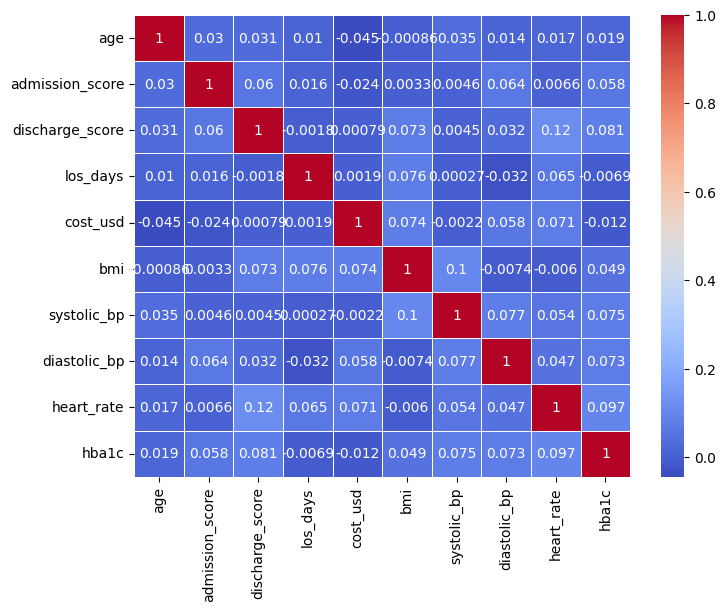

In [33]:
#heatmap
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()